## Import thư viện

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load dữ liệu

In [2]:
economy = pd.read_csv("economy_exported.csv", index_col=0)
economy.head()

,Từ Khóa,Tiêu đề,URL,Nội Dung,Ngày Cào
ID,,,,,
1,kinh tế việt nam 12/03/2026,Vietnam at the 2025 SEA Games - Wikipedia,https://en.wikipedia.org/wiki/Vietnam_at_the_2...,Vietnam at the 2025 SEA Games\n| Vietnam at th...,2026-03-12 06:14:30
2,kinh tế việt nam 12/03/2026,Chính sách tiền tệ Việt Nam: Phòng thủ trước á...,https://vneconomy.vn/tai-khoa-can-chia-lua-voi...,"Tài khóa cần ""chia lửa"" với tiền tệ trong bối ...",2026-03-12 06:14:31
3,kinh tế việt nam 12/03/2026,Phó Thủ tướng Nga thông cáo về tăng trưởng kim...,https://kevesko.vn/20260312/pho-thu-tuong-nga-...,https://kevesko.vn/20260312/pho-thu-tuong-nga-...,2026-03-12 06:14:34
4,kinh tế việt nam 12/03/2026,Việt Nam đặt mục tiêu tăng trưởng hai chữ số đ...,https://index.vn/tin-tuc/viet-nam-dat-muc-tieu...,Thế giới chưa từng có nước nào đạt được tham v...,2026-03-12 06:14:41
5,kinh tế việt nam 12/03/2026,Điểm tin kinh tế Việt Nam nổi bật ngày 11/3/2026,https://bnews.vn/diem-tin-kinh-te-viet-nam-noi...,Điểm tin kinh tế Việt Nam nổi bật ngày 11/3/20...,2026-03-12 06:14:42


In [3]:
economy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 1 to 219
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Từ Khóa   219 non-null    object
 1   Tiêu đề   219 non-null    object
 2   URL       219 non-null    object
 3   Nội Dung  219 non-null    object
 4   Ngày Cào  219 non-null    object
dtypes: object(5)
memory usage: 10.3+ KB


## Tạo tập copy & Ghép cột "Tiêu đề" và "Nội Dung"

In [4]:
economy_copy = economy.copy()
economy_copy["text"] = economy_copy["Tiêu đề"] + " " + economy_copy["Nội Dung"]

## Clean text

In [5]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)   # remove url
    text = re.sub(r"<.*?>", "", text)     # remove html
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)  # remove punctuation
    
    return text

economy_copy["clean_text"] = economy_copy["text"].apply(clean_text)

## Lọc các bài viết không liên quan (Rate hơi thấp)

#### Phương pháp TF-IDF + Cosine similarity

In [25]:
seed_texts_vi = [

"""
thị trường chứng khoán việt nam vn-index tăng giảm
cổ phiếu doanh nghiệp niêm yết giao dịch trên sàn hose hnx upcom
nhà đầu tư mua bán cổ phiếu theo diễn biến thị trường
""",

"""
chỉ số vn-index phản ánh biến động thị trường chứng khoán
các cổ phiếu vốn hóa lớn bluechip ảnh hưởng đến xu hướng thị trường
nhà đầu tư theo dõi thanh khoản và khối lượng giao dịch
""",

"""
doanh nghiệp niêm yết công bố kết quả kinh doanh
lợi nhuận doanh thu ảnh hưởng giá cổ phiếu trên thị trường chứng khoán
nhà đầu tư phân tích báo cáo tài chính trước khi đầu tư
""",

"""
sàn giao dịch chứng khoán hose hnx và upcom
niêm yết cổ phiếu của các doanh nghiệp việt nam
nhà đầu tư cá nhân và tổ chức tham gia thị trường
""",

"""
dòng tiền đầu tư vào thị trường chứng khoán
nhà đầu tư mua cổ phiếu khi vn-index tăng trưởng
thị trường tài chính phản ánh kỳ vọng kinh tế
""",

"""
khối ngoại mua bán ròng cổ phiếu trên sàn chứng khoán
thanh khoản thị trường tăng khi nhà đầu tư giao dịch mạnh
chỉ số vn-index dao động theo cung cầu cổ phiếu
""",

"""
các công ty chứng khoán đưa ra khuyến nghị đầu tư
nhà đầu tư theo dõi xu hướng vn-index và cổ phiếu bluechip
thị trường chứng khoán phản ánh kỳ vọng kinh tế
""",

"""
giá cổ phiếu của các doanh nghiệp niêm yết biến động
theo thông tin kết quả kinh doanh và triển vọng ngành
nhà đầu tư phân tích thị trường trước khi ra quyết định
"""
]

In [26]:
seed_texts_en = [

"""
Vietnam stock market VN-Index increased as investors bought shares
listed companies on HOSE HNX and UPCOM attracted strong trading volume
market liquidity improved as investors returned to equities
""",

"""
The VN-Index reflects the performance of the Vietnam stock market
large-cap blue chip stocks influence the overall market trend
investors monitor trading volume and market liquidity
""",

"""
Listed companies on the Ho Chi Minh Stock Exchange reported strong earnings
corporate profits and financial results affect stock prices
investors analyze financial statements before making investment decisions
""",

"""
Foreign investors bought and sold Vietnamese stocks
trading activity increased on HOSE and HNX exchanges
market sentiment improved as investors expected economic growth
""",

"""
Vietnam equities gained as the VN-Index moved higher
investors increased exposure to blue chip stocks
market liquidity and trading volume rose significantly
""",

"""
Stock prices of listed companies fluctuate based on earnings reports
corporate announcements and economic outlook affect investor sentiment
traders monitor market movements and investment opportunities
""",

"""
Vietnamese stock exchanges including HOSE HNX and UPCOM
provide platforms for trading shares of listed companies
domestic and foreign investors participate in the equity market
""",

"""
Securities firms issued investment recommendations
analysts expect the Vietnam stock market to grow
investors track the VN-Index and sector performance
"""
]

In [27]:
seed_texts = seed_texts_vi + seed_texts_en

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

all_texts = economy_copy["clean_text"].tolist() + seed_texts
tfidf = vectorizer.fit_transform(all_texts)

In [29]:
article_vectors = tfidf[:-len(seed_texts)]
seed_vectors = tfidf[-len(seed_texts):]

centroid = np.asarray(seed_vectors.mean(axis=0))

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(article_vectors, centroid)

In [31]:
economy_copy["topic_score"] = scores

economy_copy = economy_copy[
    economy_copy["topic_score"] > 0.15
]

#### Phương pháp word filter

In [6]:
economic_keywords = [
    "kinh tế","lạm phát","tăng trưởng", "giá cả","thị trường","đầu tư",
    "giá", "gdp","inflation","interest rate",
    "monetary","fiscal"
]

def is_economic(text):
    text = text.lower()
    
    for kw in economic_keywords:
        if kw in text:
            return True
            
    return False

economy_copy = economy_copy[economy_copy["clean_text"].apply(is_economic)]

#### Reset index

In [7]:
economy_copy = economy_copy.reset_index()
economy_copy["clean_text"].index

RangeIndex(start=0, stop=185, step=1)

In [8]:
economy_copy["clean_text"].head()

0    Chính sách tiền tệ Việt Nam  Phòng thủ trước á...
1    Phó Thủ tướng Nga thông cáo về tăng trưởng kim...
2    Việt Nam đặt mục tiêu tăng trưởng hai chữ số đ...
3    Điểm tin kinh tế Việt Nam nổi bật ngày 11 3 20...
4    Vốn đầu tư trực tiếp nước ngoài thực hiện tại ...
Name: clean_text, dtype: object

## Detect ngôn ngữ

In [9]:
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

economy_copy["lang"] = economy_copy["clean_text"].apply(detect_lang)

In [10]:
economy_copy["lang"].value_counts()

lang
vi    173
en     10
es      1
id      1
Name: count, dtype: int64

In [11]:
economy_copy = economy_copy[economy_copy["lang"].isin(["vi","en"])]
economy_copy["lang"].value_counts()

lang
vi    173
en     10
Name: count, dtype: int64

## Chuẩn hóa text

In [12]:
economy_copy["clean_text"] = economy_copy["clean_text"].str.lower()

## Word tokenize

In [38]:
from underthesea import word_tokenize

def tokenize_vi(text):
    return word_tokenize(text, format="text")

def tokenize_en(text):
    return " ".join(word_tokenize(text))

C:\Users\f\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
def tokenize(text, lang):
    if lang == "vi":
        return tokenize_vi(text)
    else:
        return tokenize_en(text)

economy_copy["token_text"] = economy_copy.apply(
    lambda x: tokenize(x["clean_text"], x["lang"]),
    axis=1
)

## Loại bỏ stopwords

In [13]:
from nltk.corpus import stopwords

stop_words_en = set(stopwords.words("english"))

stop_words_vi = {
    "và","là","của","có","cho","trong","một","những","được","với","các",
    "đã","này","đó","khi","đến","từ","ra","rằng","thì","vì","mà","nên",
    "như","để","sau","trước","vẫn","còn","cũng","lại","rất","hơn","ít",
    "nhiều","từng","tại","theo","qua","về","đi","lên","xuống","vào",
    "giữa","ngoài","trên","dưới","bên","cùng","cùng với"
}
domain_stopwords = {
    "việt nam","việt","nam",
    "theo","cho biết","cho rằng",
    "thông tin","được biết",
    "cơ quan","bộ","ngành",
    "tỷ","triệu","tỷ đồng",
    "năm","tháng","ngày"
}
stop_words_vi = stop_words_vi.union(domain_stopwords)

def remove_stopwords(text, lang):
    words = text.split()

    if lang == "vi":
        words = [w for w in words if w not in stop_words_vi and len(w) > 2]
    elif lang == "en":
        words = [w for w in words if w not in stop_words_en]

    return " ".join(words)

economy_copy["clean_text"] = economy_copy.apply(
    lambda x: remove_stopwords(x["clean_text"], x["lang"]),
    axis=1
)

## Feature extraction

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(economy_copy["token_text"])

In [42]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24641 stored elements and shape (86, 5000)>

## Tính toán sentiment

In [14]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

from transformers import pipeline

sentiment = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True
)

C:\Users\f\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu


In [15]:
def first_part(text, max_words=300):
    return " ".join(text.split()[:max_words])

In [16]:
def get_sentiment(text):
    chunks = first_part(text, max_words=300)
    results = sentiment(chunks)

    scores = []
    for r in results:
        scores.append(int(r["label"][0]))  # lấy số sao

    avg_score = sum(scores) / len(scores)
    return avg_score

economy_copy["sentiment_score"] = economy_copy["clean_text"].apply(get_sentiment)

In [17]:
economy_copy["sentiment_score"].value_counts()

sentiment_score
1.0    87
2.0    57
3.0    19
4.0    13
5.0     7
Name: count, dtype: int64

In [18]:
mapping = {
    1.0 : -2,
    2.0 : -1,
    3.0 : 0,
    4.0 : 1,
    5.0 : 2
}

economy_copy["sentiment_score_mapping"] = economy_copy["sentiment_score"].map(mapping)
economy_copy["sentiment_score_mapping"]

0     -1
1     -2
2     -1
3      0
4     -2
      ..
180   -2
181   -1
182   -1
183   -1
184   -1
Name: sentiment_score_mapping, Length: 183, dtype: int64

## Sentiment trung bình theo ngày

In [19]:
economy_copy["Ngày Cào"] = pd.to_datetime(economy_copy["Ngày Cào"])

daily_sentiment = economy_copy.groupby(
    economy_copy["Ngày Cào"].dt.date
)["sentiment_score_mapping"].mean().reset_index(name="avg_sentiment")

In [20]:
daily_sentiment

,Ngày Cào,avg_sentiment
0,2026-03-12,-1.114754


Text(0, 0.5, 'Frequency')

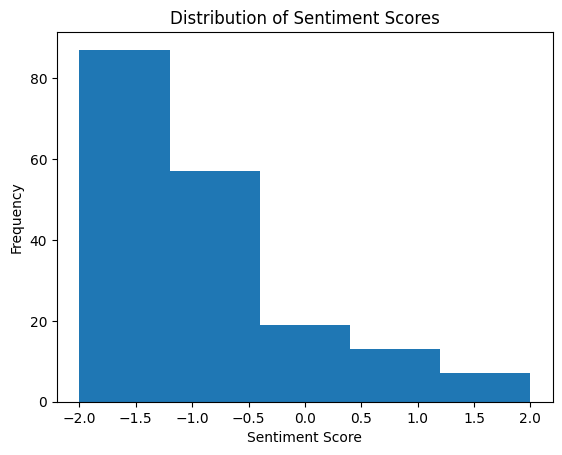

In [24]:
economy_copy["sentiment_score_mapping"].plot.hist(bins=5)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")